In [44]:
# ==========================================================
# WEEK 1 BASELINE ELECTRON RING (WORKING VERSION)
# 45.6 GeV with realistic bending radius
# ==========================================================

import xtrack as xt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [45]:

# ----------------------------------------------------------
# 1) Create Environment and Reference Particle
# ----------------------------------------------------------

env = xt.Environment()
energy_GeV = 45.6
env.set_particle_ref('electron', p0c=energy_GeV * 1e9)

c = 299792458.0


In [46]:

# ----------------------------------------------------------
# 2) Geometry Parameters (REALISTIC)
# ----------------------------------------------------------

n_cells = 200                     # increase cells -> large radius
cell_length = 200.0               # meters per cell

total_bends = n_cells * 2
bend_angle = (2 * np.pi) / total_bends
bend_length = 10.0                # meters

# This gives bending radius:
rho = bend_length / bend_angle
print("Bending radius rho ≈", round(rho/1000,2), "km")

quad_length = 2.0

# Quadrupole strengths (mild focusing)
kqf = 0.005
kqd = -0.005


Bending radius rho ≈ 0.64 km


In [47]:

# ----------------------------------------------------------
# 3) Define Elements
# ----------------------------------------------------------

env.new('mb', xt.Bend, length=bend_length, angle=bend_angle)
env.new('mqf', xt.Quadrupole, length=quad_length, k1=kqf)
env.new('mqd', xt.Quadrupole, length=quad_length, k1=kqd)
env.new('dr', xt.Drift, length=cell_length/4 - quad_length/2 - bend_length/2)


'dr'

In [48]:

# ----------------------------------------------------------
# 4) RF System
# ----------------------------------------------------------

ring_length = n_cells * cell_length
f_rev = c / ring_length
h = 10000
rf_freq = h * f_rev

rf_voltage = 800e6  # 100 MV (safe margin)

env.new('rf', xt.Cavity,
        voltage=rf_voltage,
        frequency=rf_freq,
        lag=0)


'rf'

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


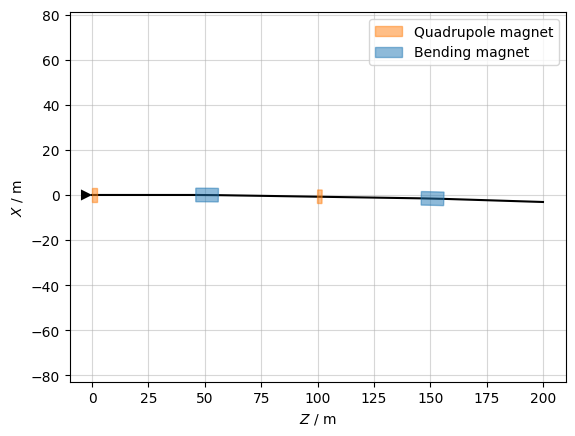

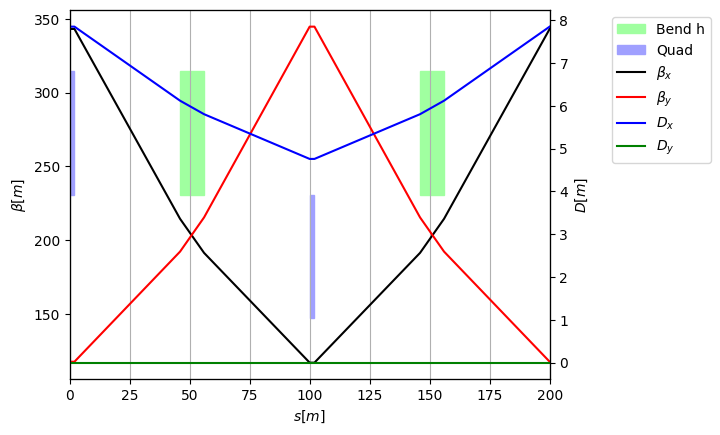


Ring circumference = 40.0 km


In [49]:

# ----------------------------------------------------------
# 5) Build Ring
# ----------------------------------------------------------
cell_components=['mqf', 'dr', 'mb', 'dr','mqd', 'dr', 'mb', 'dr']

cell = env.new_line(components=cell_components)
cell.survey().plot()

cell.twiss4d().plot()
plt.show()

ring_components = (cell_components * n_cells)
ring = env.new_line(components=['rf'] + ring_components)

ring.build_tracker()

print("\nRing circumference =", ring.get_length()/1000, "km")


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


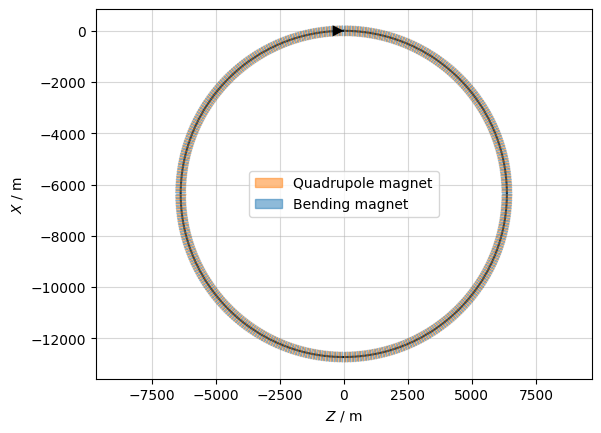

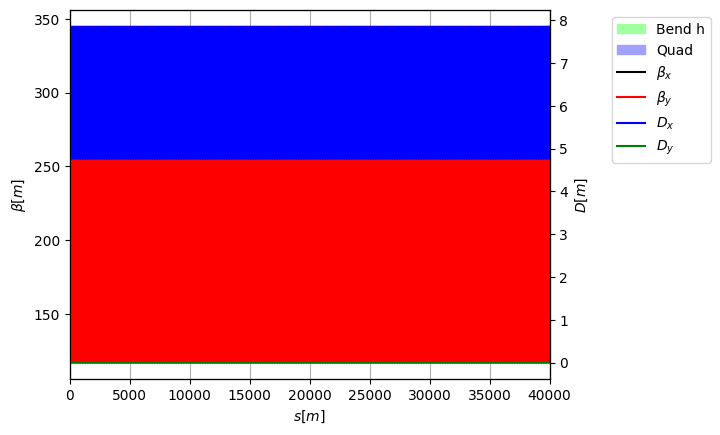


--- 4D OPTICS ---
Qx = 33.2473
Qy = 33.0877
Chromaticity Q'x = -36.366
Chromaticity Q'y = -36.394

|Tr(Mx)| = 0.034262927462903825
|Tr(My)| = 1.7041687446719416


Text(0, 0.5, 'Qy')

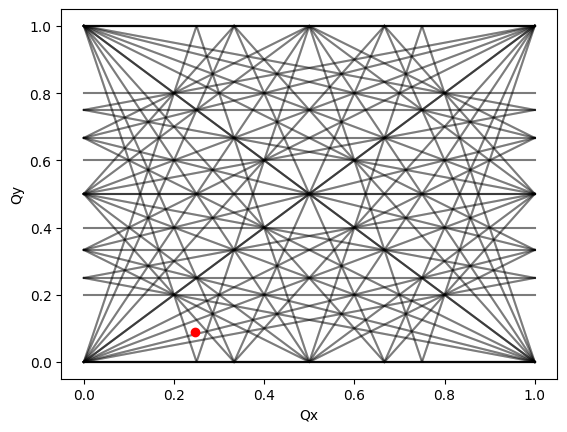

In [50]:

# ----------------------------------------------------------
# 6) 4D Twiss (No Radiation)
# ----------------------------------------------------------

tw4 = ring.twiss(method='4d')

ring.survey().plot()

ring.twiss4d().plot()
plt.show()

print("\n--- 4D OPTICS ---")
print(f"Qx = {tw4.qx:.4f}")
print(f"Qy = {tw4.qy:.4f}")
print(f"Chromaticity Q'x = {tw4.dqx:.3f}")
print(f"Chromaticity Q'y = {tw4.dqy:.3f}")

# Stability check
Mx = tw4.R_matrix[0:2,0:2]
My = tw4.R_matrix[2:4,2:4]
print("\n|Tr(Mx)| =", abs(np.trace(Mx)))
print("|Tr(My)| =", abs(np.trace(My)))


qx=tw4.qx %1
qy=tw4.qy %1

N=5
x=np.linspace(0,1,1000)
for m in range(-N,N+1):
    for n in range(-N,N+1):
        if m==0 and n==0:

            continue
        order=abs(m)+abs(n)
        if order >N:
            continue
        for k in range (-N,N+1):
            if n!=0:
                y=(k-m*x)/n
                mask=(y>=0)&(y<=1)
                plt.plot(x[mask],y[mask],'k-',alpha=0.3)
plt.plot(qx,qy,'ro',label='Working Point')
plt.xlabel('Qx')
plt.ylabel('Qy')



In [51]:

# ----------------------------------------------------------
# 7) Turn On Radiation
# ----------------------------------------------------------
ring.replace_all_repeated_elements()
ring.configure_radiation(model='mean')
ring.compensate_radiation_energy_loss()

tw6 = ring.twiss(method='6d', eneloss_and_damping=True)

print("\n--- 6D WITH RADIATION ---")

# Radiation integrals
print(tw6['eneloss_turn']) #provides the energy loss per turn (in eV).
print(tw6['damping_constants_s']) #provides the damping constants in x, y and zeta.
print(tw6['partition_numbers']) #provides the corresponding damping partion numbers.
print(tw6['eq_nemitt_x']) #provides the equilibrium horizontal emittance.
print(tw6['eq_nemitt_y']) #provides the equilibrium vertical emittance.
print(tw6['eq_nemitt_zeta']) #provides the equilibrium longitudinal emittance.


Compensating energy loss.
Share energy loss among cavities (repeat until energy loss is zero)
Energy loss: 585_489_205.224 eV             
Energy loss: 30_044_213.805 eV             
Energy loss: 1_571_451.445 eV             
Energy loss: 82_274.702 eV             
Energy loss: 4_307.784 eV             
Energy loss: 225.550 eV             
Energy loss: 11.809 eV             
Energy loss: 0.618 eV             
Energy loss: -15_879_881.638 eV             
Energy loss: -1_228_616.470 eV             
Energy loss: 719_890.026 eV             
Energy loss: 118_786.925 eV             
Energy loss: -27_771.377 eV             
Energy loss: -8_248.181 eV             
Energy loss: 787.652 eV             
Energy loss: 484.454 eV             
Energy loss: -2.953 eV             

  - Set delta_taper
  - Restore cavity voltage and frequency. Set cavity lag

--- 6D WITH RADIATION ---
600847524.3974136
[48.85524127 49.37666052 99.27814709]
[0.98945626 1.00001647 2.01066215]
0.09362223002090175
5.1151762

In [52]:

# ----------------------------------------------------------
# 8) Spin Tune Estimate
# ----------------------------------------------------------

a_e = 0.001159652
gamma = ring.particle_ref.gamma0[0]
nu_s = a_e * gamma

print("\n--- SPIN ---")
print("Gamma =", gamma)
print("Spin tune νs =", nu_s)



--- SPIN ---
Gamma = 89236.97397590183
Spin tune νs = 103.4838353451025


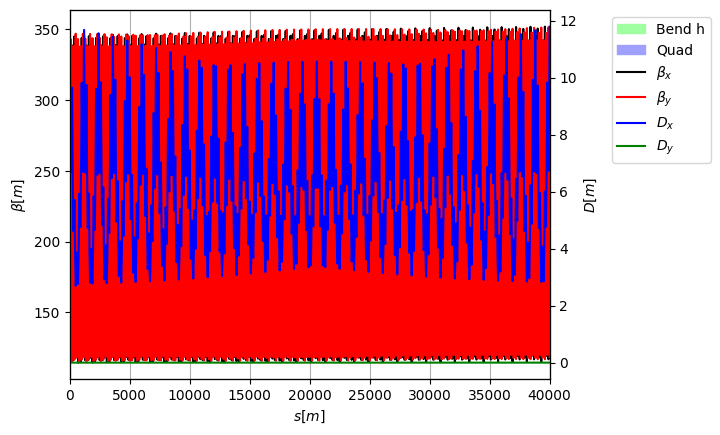

In [53]:

# ----------------------------------------------------------
# 9) Plot Beta and Dispersion
# ----------------------------------------------------------

tw6.plot()
plt.show()
